# Model Development

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import tensorflow as tf

### Load Data and Preprocess (normalize, one hot encode & split)

In [2]:
# Load Dataset
data = pd.read_csv("transactions.csv")

In [3]:
data.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,0,86400,68.5,W,13926,0.0,150.0,discover,142.0,credit,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Seperate Features and Label
target_column = "isFraud"
X = data.drop(columns=[target_column])
y = data[target_column]

In [5]:
# Split Numeric and Categorical data
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

In [6]:
# Normalize numeric features
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [7]:
# One-hot encode categorical features using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32) # Create encoder instance
encoded_data = encoder.fit_transform(X[categorical_columns]) # Fit and transform on categorical features

# Get feature names after encoding
feature_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame for the encoded features
encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=X.index)

# Concatenate encoded features with numeric features
X = pd.concat([X[numeric_columns], encoded_df], axis=1)

In [8]:
# Check result
X.head()

,TransactionDT,TransactionAmt,card1,card2,card3,card5,C1,C2,C3,C4,...,card4_0,card4_american express,card4_discover,card4_mastercard,card4_visa,card6_0,card6_charge card,card6_credit,card6_debit,card6_debit or credit
0,-1.577987,-0.278167,0.821695,-2.194286,-0.202222,-1.257118,-0.098020,-0.092260,-0.037493,-0.059438,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.577986,-0.443327,-1.457558,0.288389,-0.202222,-2.157605,-0.098020,-0.092260,-0.037493,-0.059438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.577972,-0.317889,-1.068263,0.816879,-0.202222,-0.716826,-0.098020,-0.092260,-0.037493,-0.059438,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.577965,-0.355521,1.679858,1.290062,-0.202222,-1.819922,-0.090533,-0.066398,-0.037493,-0.059438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.577964,-0.355521,-1.102133,0.964364,-0.202222,-2.157605,-0.098020,-0.092260,-0.037493,-0.059438,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
y.head()

,isFraud
0,0
1,0
2,0
3,0
4,0


In [10]:
# Convert to TF compatible format
# X = np.nan_to_num(X).astype(np.float32)
# y = np.nan_to_num(y).astype(np.float32)

In [11]:
# Split into train and temp sets (70% train, 30% temp)
# stratify by 'y' (your target variable) to maintain fraud proportion
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temp into validation and test sets (50% each of the temp set)
# stratify by 'y_temp' to maintain fraud proportion in these sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

### Create Model

In [68]:
class CustomAdam(tf.keras.optimizers.Adam):
    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7, name="CustomAdam", **kwargs):
        super(CustomAdam, self).__init__(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2, epsilon=epsilon, name=name, **kwargs)

    def _resource_apply_dense(self, grad, var, apply_state=None):
        """Apply gradients to dense tensors (regular variables)."""

        var_device, var_dtype = var.device, var.dtype.base_dtype
        coefficients = ((apply_state or {}).get((var_device, var_dtype))
                        or self._fallback_apply_state(var_device, var_dtype))

        # Accessing slots using coefficients
        m = self.get_slot(var, "m")
        v = self.get_slot(var, "v")

        # Custom Math Implementation (AdaBelief)
        beta_1_power, beta_2_power = coefficients['beta_1_power'], coefficients['beta_2_power']
        lr_t = coefficients['lr_t']

        # Compute first and second moments (mean and variance)
        m.assign(self.beta_1 * m + (1.0 - self.beta_1) * grad)
        v.assign(self.beta_2 * v + (1.0 - self.beta_2) * tf.square(grad))

        # AdaBelief-specific: Compute the discrepancy between gradient and moment
        s = v - tf.square(m)  # This is the key difference from standard Adam

        # Compute the bias-corrected estimates
        m_hat = m / (1.0 - beta_1_power)
        v_hat = v / (1.0 - beta_2_power)

        # Update the variable using the AdaBelief formula
        var.assign_sub(lr_t * m_hat / (tf.math.sqrt(v_hat) + self.epsilon))


        # Adam update
        m.assign(self.beta_1 * m + (1.0 - self.beta_1) * grad, use_locking=self._use_locking) # Using the default Adam moment update
        v.assign(self.beta_2 * v + (1.0 - self.beta_2) * tf.square(grad), use_locking=self._use_locking) # Using the default Adam velocity update

        m_hat = m / (1.0 - beta_1_power)
        v_hat = v / (1.0 - beta_2_power)

        var.assign_sub(lr_t * m_hat / (tf.sqrt(v_hat) + self.epsilon), use_locking=self._use_locking) # Using the default Adam update rule


    def _resource_apply_sparse(self, grad, var, indices, apply_state=None):
        """Override sparse gradient updates with a pass since they are not supported."""
        pass

    def get_config(self):
        config = super().get_config()
        return config

In [69]:
# def custom_loss(y_true, y_pred):
#        false_negative_weight = 2.0  # Adjust this weight
#        binary_crossentropy = tf.keras.losses.BinaryCrossentropy()
#        loss = binary_crossentropy(y_true, y_pred)

#        # Add weight to false negatives
#        false_negatives = tf.math.multiply(tf.cast(y_true, tf.float32), (1 - tf.cast(y_pred, tf.float32)))
#        weighted_false_negatives = tf.math.multiply(false_negatives, false_negative_weight)
#        loss = tf.math.add(loss, tf.reduce_sum(weighted_false_negatives))

#        return loss


def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer=CustomAdam(learning_rate=0.001),
                  loss="binary_crossentropy",
                  metrics=['precision', 'recall', 'accuracy', 'AUC'])
    return model

In [70]:
# Create model
model = create_model()

# Reset the index of y_train and y_val before fitting
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

history = model.fit(X_train, y_train, epochs=10, batch_size=2048, validation_data=(X_val, y_val), class_weight={0:1, 1:7})

Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - AUC: 0.7841 - accuracy: 0.9237 - loss: 0.4986 - precision: 0.2028 - recall: 0.3274 - val_AUC: 0.8497 - val_accuracy: 0.9526 - val_loss: 0.1798 - val_precision: 0.3458 - val_recall: 0.3968
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8593 - accuracy: 0.9440 - loss: 0.4094 - precision: 0.3041 - recall: 0.4656 - val_AUC: 0.8628 - val_accuracy: 0.9517 - val_loss: 0.1725 - val_precision: 0.3528 - val_recall: 0.4565
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8720 - accuracy: 0.9483 - loss: 0.3869 - precision: 0.3362 - recall: 0.5010 - val_AUC: 0.8684 - val_accuracy: 0.9595 - val_loss: 0.1588 - val_precision: 0.4248 - val_recall: 0.4410
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8808 - accuracy: 0.9500 - loss: 0.3747 - precision: 0.3559 - recall: 0.5288 - val_AUC: 0.8728 - val_accuracy: 0.9540 - val_loss: 0.1590 - val_precision: 0.3796 - val_recall: 0.4945
Epoch 5/10
202/202 ━━━━━━━━━━━

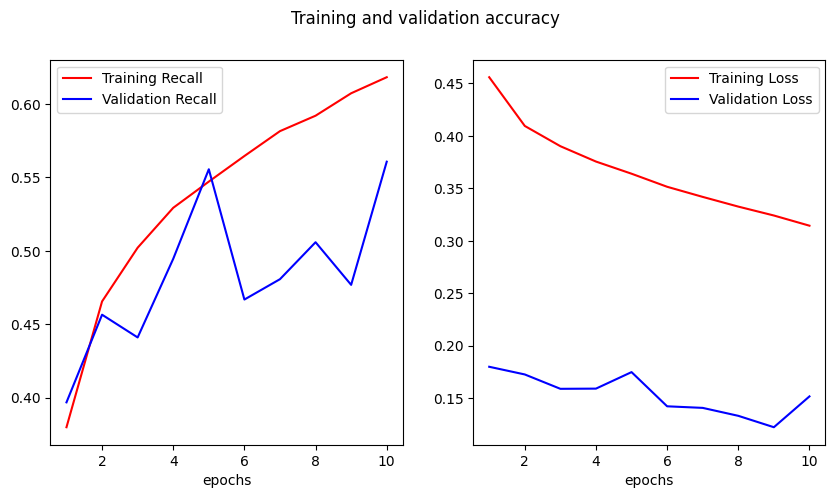

In [71]:
# Get training and validation recall
recall = history.history['recall']
val_recall = history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(1, len(recall) + 1) # Generate a sequence of numbers from 1 to the number of epochs trained

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Training and validation accuracy')

for i, (data, label) in enumerate(zip([(recall, val_recall), (loss, val_loss)], ["Recall", "Loss"])):
    ax[i].plot(epochs, data[0], 'r', label="Training " + label)
    ax[i].plot(epochs, data[1], 'b', label="Validation " + label)
    ax[i].legend()
    ax[i].set_xlabel('epochs')

plt.show()

In [ ]:
# Evaluate
loss, precision, recall, accuracy, AUC = model.evaluate(X_test, y_test, verbose=0)

# Print the evaluation metrics
print("Test Loss:", loss)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test Accuracy:", accuracy)
print("Test AUC:", AUC)

Test Loss: 0.13740237057209015
Test Precision: 0.44337978959083557
Test Recall: 0.6569861173629761
Test Accuracy: 0.9591447114944458
Test AUC: 0.9022170901298523


In [ ]:
f1_score = 2 * (precision * recall) / (precision + recall)
print("Test F1-score:", f1_score)

Test F1-score: 0.5294500032028411


2769/2769 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


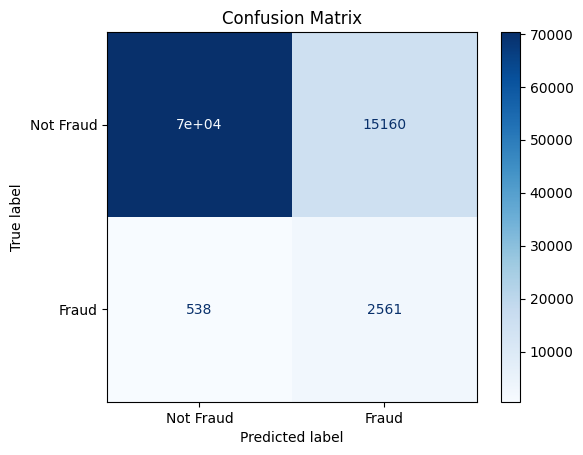

              precision    recall  f1-score   support

           0       0.99      0.82      0.90     85482
           1       0.14      0.83      0.25      3099

    accuracy                           0.82     88581
   macro avg       0.57      0.82      0.57     88581
weighted avg       0.96      0.82      0.88     88581



In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.1).astype(int)  # Convert probabilities to class labels (0 or 1)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_test, y_pred_classes)
print(class_report)